Evaluating the model trained with **Sentinel-1 GRD** data (IW mode, VV+VH polarization).

# 0. Setup

## 0.1. Libraries

In [56]:
# Utilities
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import gc
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# Deep learning
import torch
from torch import nn, utils
from torchmetrics import classification

# Custom library
from library import nn_model, utilities, visualizations, preprocessing
from library.visualizations.visualize_predictions import visualize_predictions

# Device selection
device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
device = torch.device(device)
print(f'Using device: {device}')

# Utilities
seed = 42  # Set the same seed as for the corresponding training run with S2-L2A data!
utilities.set_seed(seed)

Using device: cpu
Seed set to 42 for NumPy, Torch and Random for reproducibility.


## 0.2. Setting the path to the data

We set the path to the tiles that have been created in the preprocessing notebook, `3_preprocessing.ipynb`.

In [21]:
# base_input_dir = '/media/pablo/Shared files/data/'  # Adjust this path to your data directory containing the labelled dataset
base_input_dir = 'C:/Users/blanc/OneDrive/Desktop/DSDM/3-ImageProcessing/FINAL_HW/'
input_labelled_dir = os.path.join(base_input_dir, 'Satellite_burned_area_dataset')  # Path to the original labelled dataset
tile_dir = os.path.join(base_input_dir, 'tiled_labelled_dataset')  # Path to the tiled dataset
sentinel_type = 1  # Sentinel-2 data

## 0.3. Notebook description

In this notebook we evaluate the model trained on Sentinel-1 GRD images on the test split made in that notebook.

# 1. Preparing the data

## 1.1. Getting the image and masks paths

In [22]:
# Get all of the folders within the tiles directory
fire_folders = sorted([f for f in os.listdir(tile_dir) if os.path.isdir(os.path.join(tile_dir, f))])
# Print the first 5 folders
print("First 5 fire folders:")
print(fire_folders[:5])
# Print the total number of fire folders
print("Total number of fire folders:", len(fire_folders))

# Get the paths for the images and the labels
image_paths = []
label_paths = []
for fire_folder in fire_folders:
    # print(f"Fire folder: {fire_folder}")
    images_path = os.path.join(tile_dir, fire_folder, 'images')
    labels_path = os.path.join(tile_dir, fire_folder, 'masks')
    if os.path.exists(images_path):
        image_paths.append(sorted([os.path.join(images_path, img) for img in os.listdir(images_path) if img.startswith(f'sentinel{sentinel_type}') and img.endswith('.tiff')]))
    else:
        print(f"Images path does not exist: {images_path}")
    if os.path.exists(labels_path):
        label_paths.append(sorted([os.path.join(labels_path, lbl) for lbl in os.listdir(labels_path) if lbl.endswith('.tiff')]))
    else:
        print(f"Labels path does not exist: {labels_path}")

First 5 fire folders:
['EMSR207_01MIRANDADOCORVO_02GRADING_MAP_v2_vector', 'EMSR207_02LOUSA_02GRADING_MAP_v2_vector', 'EMSR207_03PAMPILHOSADASERRA_02GRADING_MAP_v2_vector', 'EMSR207_04AVELAR_02GRADING_MAP_v2_vector', 'EMSR207_05PEDROGAOGRANDE_02GRADING_MAP_v2_vector']
Total number of fire folders: 73


## 1.2. Loading the image and masks into tensors

We load the images and labels as `torch.Tensor` of dimensions $n \times d \times h \times w$, where:
- $n$: number of images (tiles)/masks.
- $d$: number of channels for the images/masks.
- $h$: height of the images and of the masks. Both are of 256 height, as designed in `3_preprocessing`.
- $w$: width of the images and of the masks. Both are of 256 height, as designed in `3_preprocessing`.

We normalize each channel to $N[0,1]$ and set the data type as `torch.float32` (set to `torch.float16` for greater memory efficiency). Why we normalize image channels:

1. **Gradient stability**: Different channels may have vastly different value ranges, leading to unstable gradients
2. **Training speed**: Normalized inputs help the optimizer converge faster
3. **Weight initialization**: Most weight initialization schemes assume normalized inputs
4. **Activation functions**: Work optimally with inputs in specific ranges

In [23]:
from library.utilities.build_path_dictionary import build_path_dictionary

input_dir = 'C:/Users/blanc/OneDrive/Desktop/DSDM/3-ImageProcessing/FINAL_HW/'
tiles_path = os.path.join(input_dir, 'tiled_labelled_dataset')
tiles_dict = build_path_dictionary(tiles_path)

In [ ]:
images = torch.stack([utilities.read_tiff_to_torch(file_path = image, dtype=torch.float32, normalize=True, normalization_method='per_channel') for image in tiles_dict['sentinel1']])
labels_raw = torch.stack([utilities.read_tiff_to_torch(file_path = label, dtype = torch.float32, normalize=True, normalization_method='255') for label in tiles_dict['masks']])  

Now, let's check the array dimensions and display several image–label pairs to ensure that they are correctly aligned.

In [26]:
print('Size of the image tensor (pablo):', images.size())
print('Size of the label tensor (pablo):', labels_raw.size())

if images.size(0) != labels_raw.size(0):
    print('⚠️Number of images and labels do not match!')

Size of the image tensor (pablo): torch.Size([3176, 4, 256, 256])
Size of the label tensor (pablo): torch.Size([3230, 1, 256, 256])
⚠️Number of images and labels do not match!


Let's find the mismatches:

In [36]:
from pathlib import Path
import os

# Build sets of IDs from sentinel1 and mask paths
sentinel1_ids = {}
mask_ids = {}

# Build ID -> path mappings for easier comparison
for p in tiles_dict['sentinel1']:
    path = Path(p)
    parent_event = path.parent.parent.name  # event folder name
    parts = path.stem.split('_')
    tile_part = f"tile_{parts[-2]}_{parts[-1]}"
    uid = f"{parent_event}_{tile_part}"
    sentinel1_ids[uid] = p

for p in tiles_dict['masks']:
    path = Path(p)
    parent_event = path.parent.parent.name
    parts = path.stem.split('_')
    tile_part = '_'.join(parts[-3:])  # 'tile_X_Y'
    uid = f"{parent_event}_{tile_part}"
    mask_ids[uid] = p

# Find mismatches
only_in_sentinel1 = set(sentinel1_ids.keys()) - set(mask_ids.keys())
only_in_masks = set(mask_ids.keys()) - set(sentinel1_ids.keys())

print(f'Number of expected mismatches: {abs(images.size(0) - labels_raw.size(0))}')
print(f'Number of actual mismatches: {len(only_in_sentinel1) + len(only_in_masks)}')

print(f"\nOnly in Sentinel-1 ({len(only_in_sentinel1)}): {list(only_in_sentinel1)[:5]}")
print(f"Only in Sentinel-1 ({len(only_in_masks)}): {list(only_in_masks)[:5]}")


Number of expected mismatches: 54
Number of actual mismatches: 54

Only in Sentinel-1 (0): []
Only in Sentinel-1 (54): ['EMSR368_AOI01_GRA_PRODUCT_r1_RTP01_v3_vector_tile_1_1', 'EMSR368_AOI01_GRA_PRODUCT_r1_RTP01_v3_vector_tile_5_4', 'EMSR368_AOI01_GRA_PRODUCT_r1_RTP01_v3_vector_tile_1_6', 'EMSR368_AOI01_GRA_PRODUCT_r1_RTP01_v3_vector_tile_4_8', 'EMSR368_AOI01_GRA_PRODUCT_r1_RTP01_v3_vector_tile_1_0']


In [38]:
# dropping unmatched masks from the list of paths and importing again
unmatched_mask_paths = [mask_ids[uid] for uid in only_in_masks if uid in mask_ids]
filtered_masks = [label for label in tiles_dict['masks'] if label not in unmatched_mask_paths]

images = torch.stack([utilities.read_tiff_to_torch(file_path = image, dtype=torch.float32, normalize=True, normalization_method='per_channel') for image in tiles_dict['sentinel1']])
labels_raw = torch.stack([utilities.read_tiff_to_torch(file_path = label, dtype = torch.float32, normalize=True, normalization_method='255') for label in filtered_masks])  

print('Size of the image tensor (pablo):', images.size())
print('Size of the label tensor (pablo):', labels_raw.size())

if images.size(0) != labels_raw.size(0):
    print('⚠️Number of images and labels do not match!')
else:
    print('Now they match!')

Size of the image tensor (pablo): torch.Size([3176, 4, 256, 256])
Size of the label tensor (pablo): torch.Size([3176, 1, 256, 256])
Now they match!


i.e., in this case:

- $n$: we have 3,176 images and masks (3,374 images before removing those without coverage in the EDA notebook; and there were 54 images missing images from Sentinel-1 for a wildfire in the dataset).
- $d$: number of channels for the images/masks. The images have 4 dimensions (see https://documentation.dataspace.copernicus.eu/APIs/SentinelHub/Data/S1GRD.html#available-bands-and-data).
- $h$: height of the images and of the masks. Both are of 256 height, as designed in `3_preprocessing`.
- $w$: width of the images and of the masks. Both are of 256 height, as designed in `3_preprocessing`.

## 1.3. Mapping the classes to integers 

In [39]:
# Apply the mapping
labels = utilities.map_labels_to_classes_approximate(labels_raw)

del labels_raw  # Free up memory

In [40]:
# Print the unique values in the labels tensor to verify the mapping
print("Unique values in the labels tensor after mapping:", torch.unique(labels))

Unique values in the labels tensor after mapping: tensor([0, 1, 2, 3, 4])


## 1.4. Formatting the data as a `TensorDataset`

Useful documentation: [`torch.utils.data`](https://pytorch.org/docs/stable/data.html)

In [41]:
# Format the data as a TensorDataset
dataset = utils.data.TensorDataset(images, labels)  # Create a TensorDataset from the image and label tensors
print(len(dataset))

3176


## 1.5. Splitting data into train, validation and test

We split into 70% training data, 15% validation and 15% test.

> Ensure that the seed is set to the same number as the model that is going to be used for prediction (check in the filename).

In [42]:
# Split the dataset into training, validation and test sets
train_dataset, val_dataset, test_dataset = utils.data.random_split(dataset, [0.7, 0.15, 0.15], generator=torch.Generator().manual_seed(seed))

# Set batch size
batch_size = 64

# Set number of physical CPU cores (as int) to use for data loading
num_workers = os.cpu_count() // 2 if os.cpu_count() is not None else 0

# Create DataLoader just for the test dataset
test_loader = utils.data.DataLoader(
    test_dataset, 
    batch_size=batch_size, 
    shuffle=False,  # Keep test data in the same order for consistent evaluation
    num_workers=num_workers,  # Use multiple workers for faster data loading
    pin_memory=True if device == 'cuda' else False,  # Pin memory for faster data transfer to GPU
)

In [43]:
del dataset , train_dataset, val_dataset 
del images , labels
gc.collect()

1740

# 2. Error analysis with the test set

## 2.1. Loading a saved PyTorch model

Check the `models` directory within this repo. In principle, opt for the models with the lowest validation loss.

To load a save model, we need to:
1. Initialize a new model with the same architecture
2. Load the state dictionary from the saved file (in the section "Estimating the model weights", this is done in the line `torch.save(model.state_dict(), [...])`)
3. Apply the state dictionary to the model

All of these steps are automatically implemented with the `load_model` function of the `library`.

In [44]:
model_name = 'unet_sentinel1_seed42_epochs_300_val_loss_1.3612.pth'

model = utilities.load_model(os.path.join('models', model_name))

Loaded model from models\unet_sentinel1_seed42_epochs_300_val_loss_1.3612.pth with parameters: {'n_channels': 4, 'n_classes': 5, 'base_filters': 8, 'dropout_p': 0.1, 'bilinear': False}
Best validation loss: 1.3612


## 2.2. Predict probabilities for test images

For more information, check the `predict` function in the `library`. It follows the same logic as the `train_model` function, but is optimized for inference.

In [45]:
# Make predictions on the test set
test_probabilities, test_labels = nn_model.predict(model=model,
                                                   dataloader=test_loader,
                                                   device=device,
                                                   num_classes=5,  # Number of classes (0-4)
                                                   return_probs=True,  # Get prediction (softmax) probabilities
                                                   )

test_predictions = torch.argmax(test_probabilities, dim=1)  # Get the predicted labels (max probability)

print(f"Probabilities shape: {test_probabilities.shape}")
print(f"Predictions shape: {test_predictions.shape}")
print(f"Labels shape: {test_labels.shape}")

Generating predictions: 100%|██████████| 8/8 [00:10<00:00,  1.35s/it]


Probabilities shape: torch.Size([476, 5, 256, 256])
Predictions shape: torch.Size([476, 256, 256])
Labels shape: torch.Size([476, 256, 256])


## 2.3. Visualizing sample images and their predictions

In [46]:
# Get a batch of test images and their labels
test_images_sample = []
test_true_masks_sample = []

# Extract a few batches from the test loader
for images, labels in test_loader:
    test_images_sample.append(images)
    test_true_masks_sample.append(labels.squeeze(1))
    if len(test_images_sample) >= 3:  # Get 3 batches at most
        break

# Concatenate batches
test_images_sample = torch.cat(test_images_sample, dim=0)
test_true_masks_sample = torch.cat(test_true_masks_sample, dim=0)

# Make predictions (just for 3 batches)
with torch.no_grad():
    model.eval()
    # Get raw logits from the model [N, C, H, W]
    test_pred_logits = model(test_images_sample.to(device)).cpu()
    # Get predicted class for each pixel by taking the argmax along the class dimension
    test_pred_masks_sample = torch.argmax(test_pred_logits, dim=1)

In [47]:
del model
gc.collect()

9

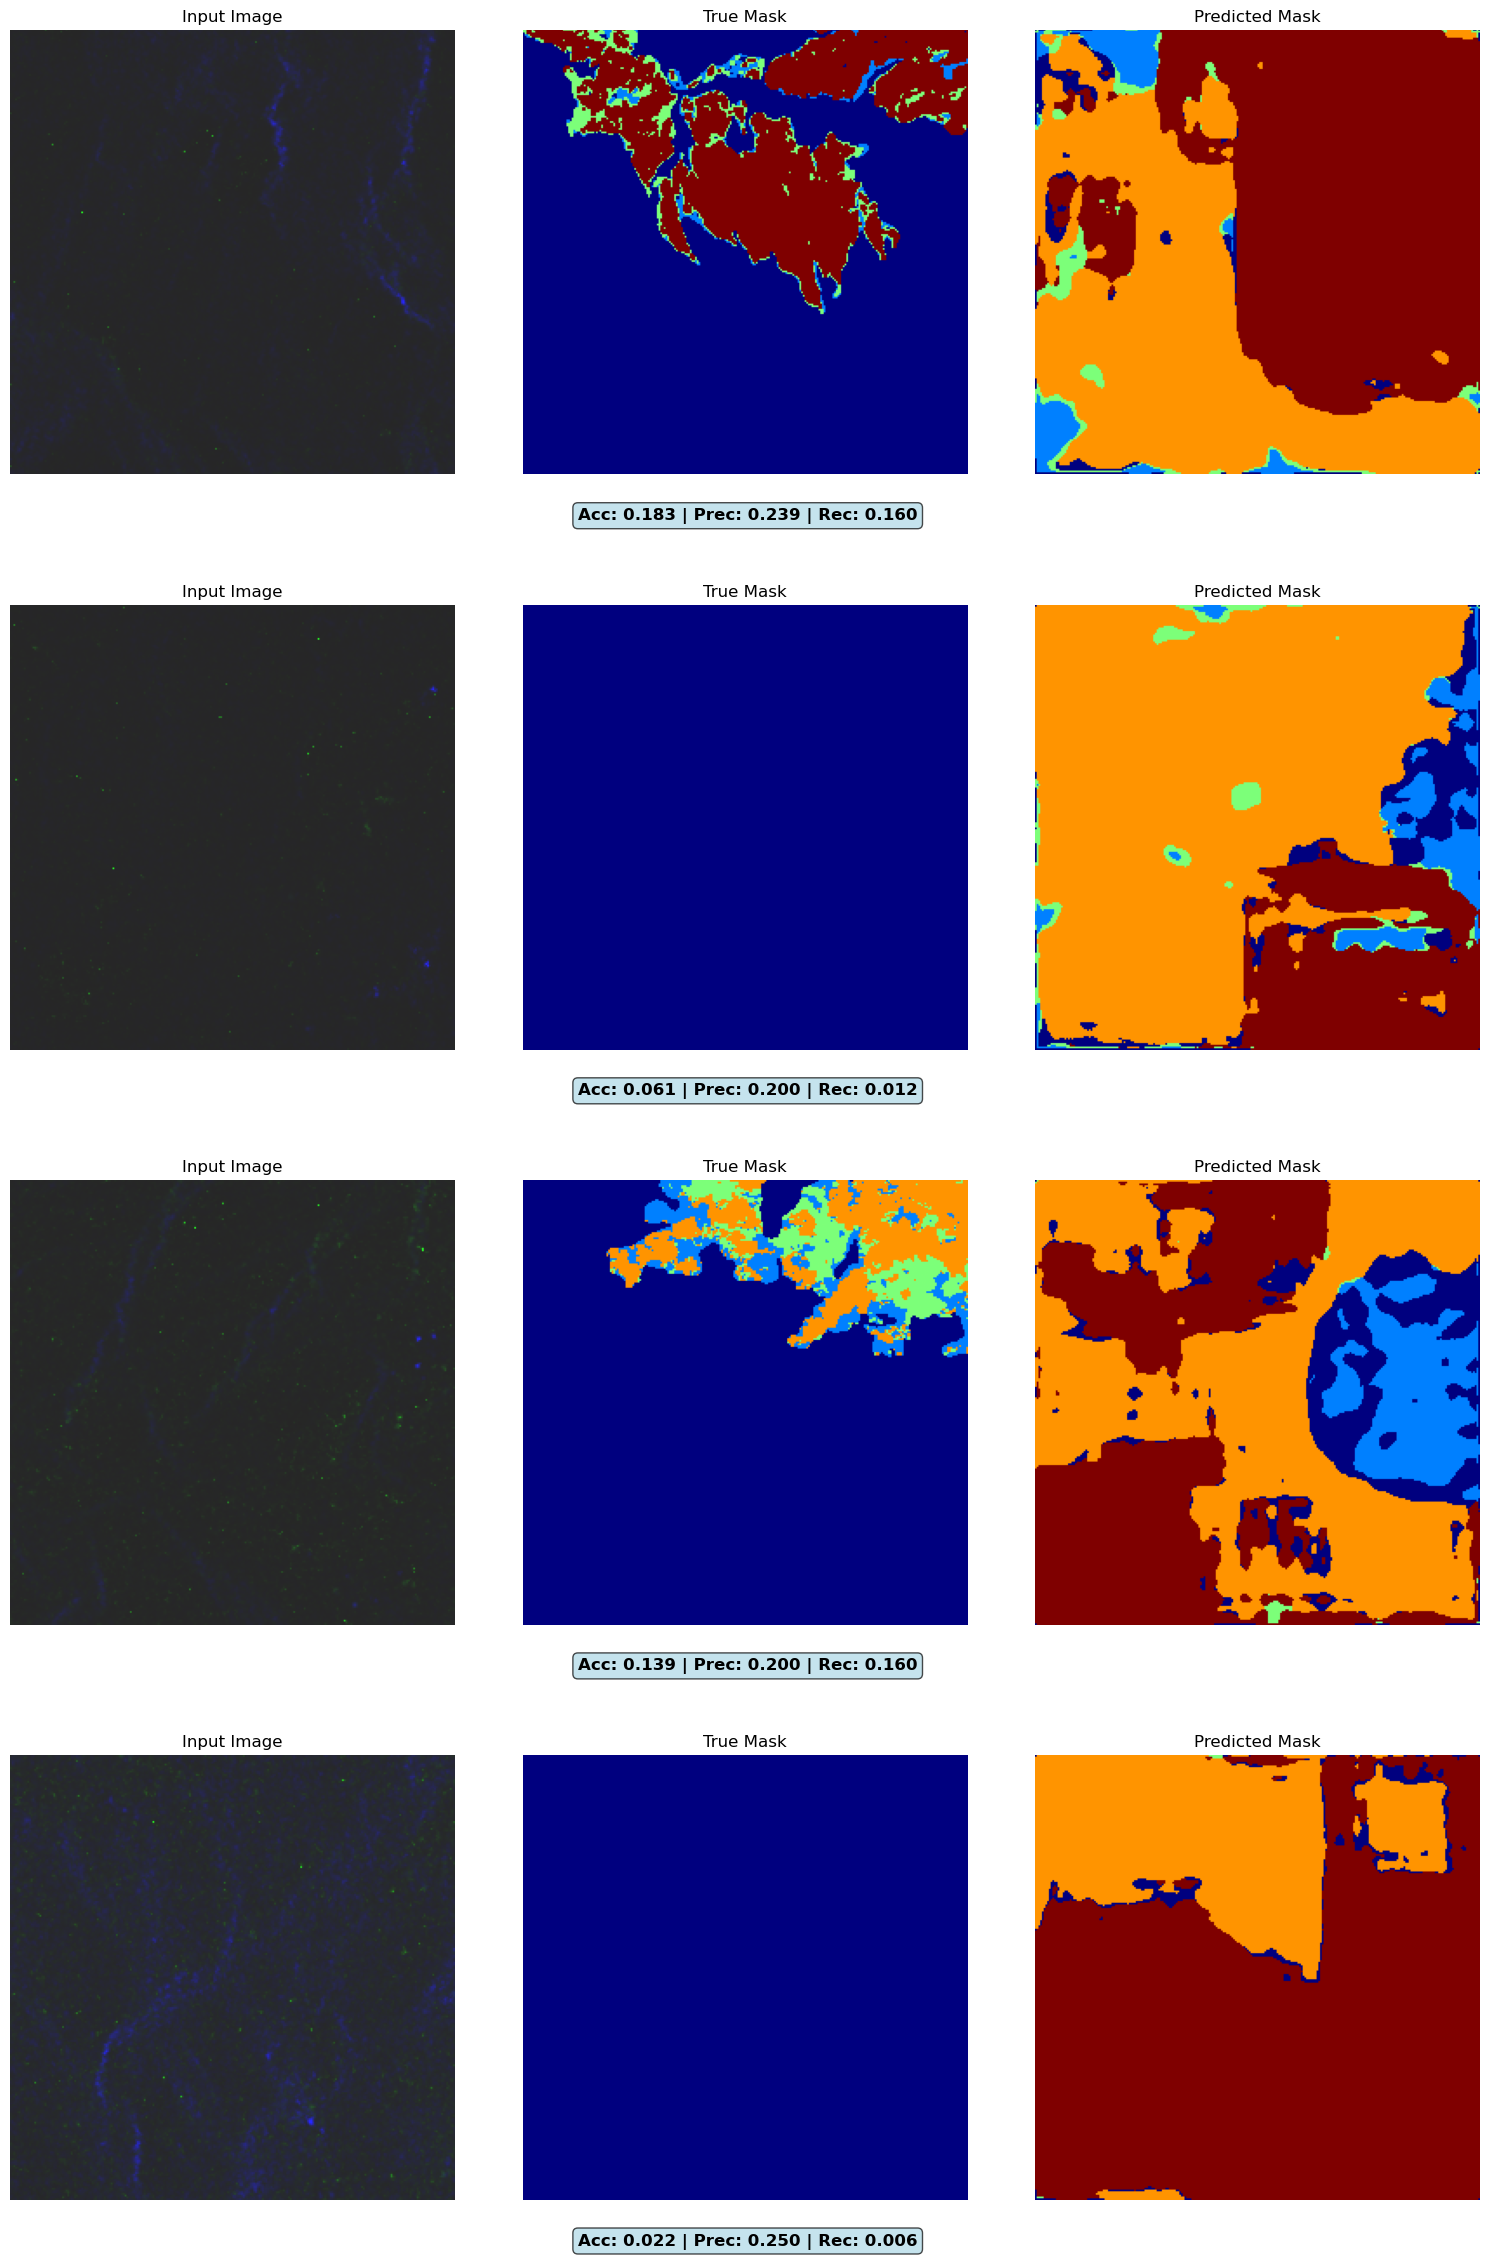

In [48]:
visualize_predictions(images=test_images_sample, 
                      true_masks=test_true_masks_sample,
                      predictions=test_pred_masks_sample, 
                      num_samples=4, num_classes=5
                      )

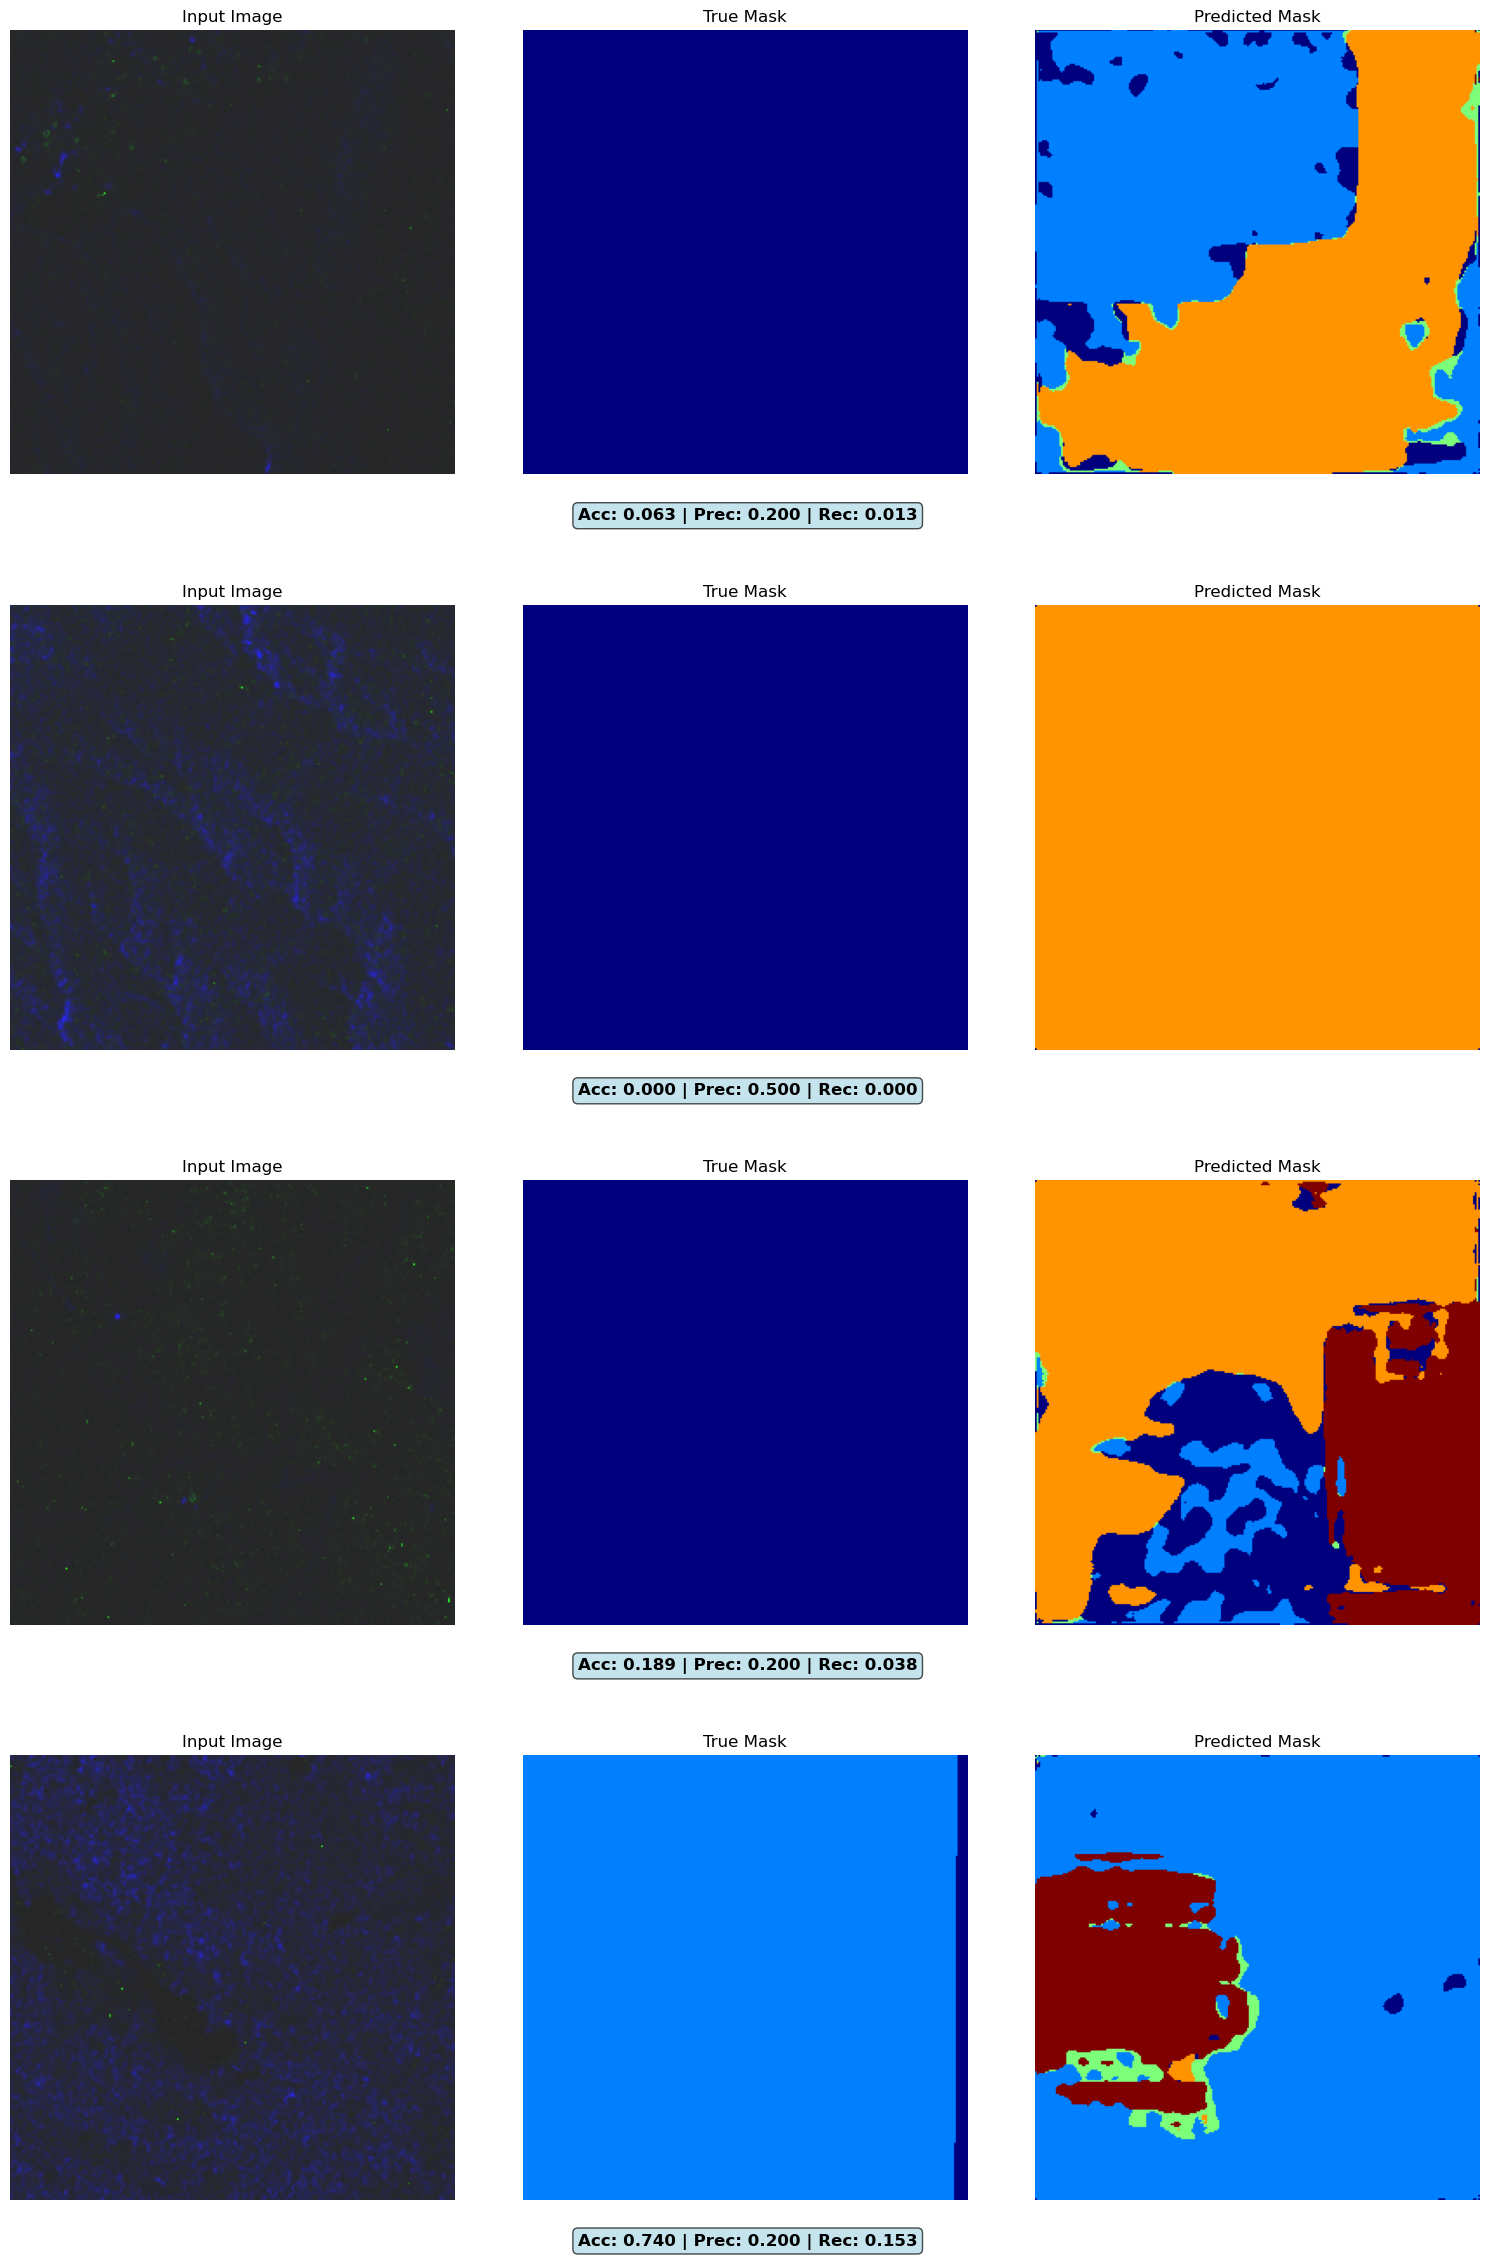

In [49]:
visualize_predictions(images=test_images_sample, 
                      true_masks=test_true_masks_sample,
                      predictions=test_pred_masks_sample, 
                      num_samples=4, num_classes=5
                      )

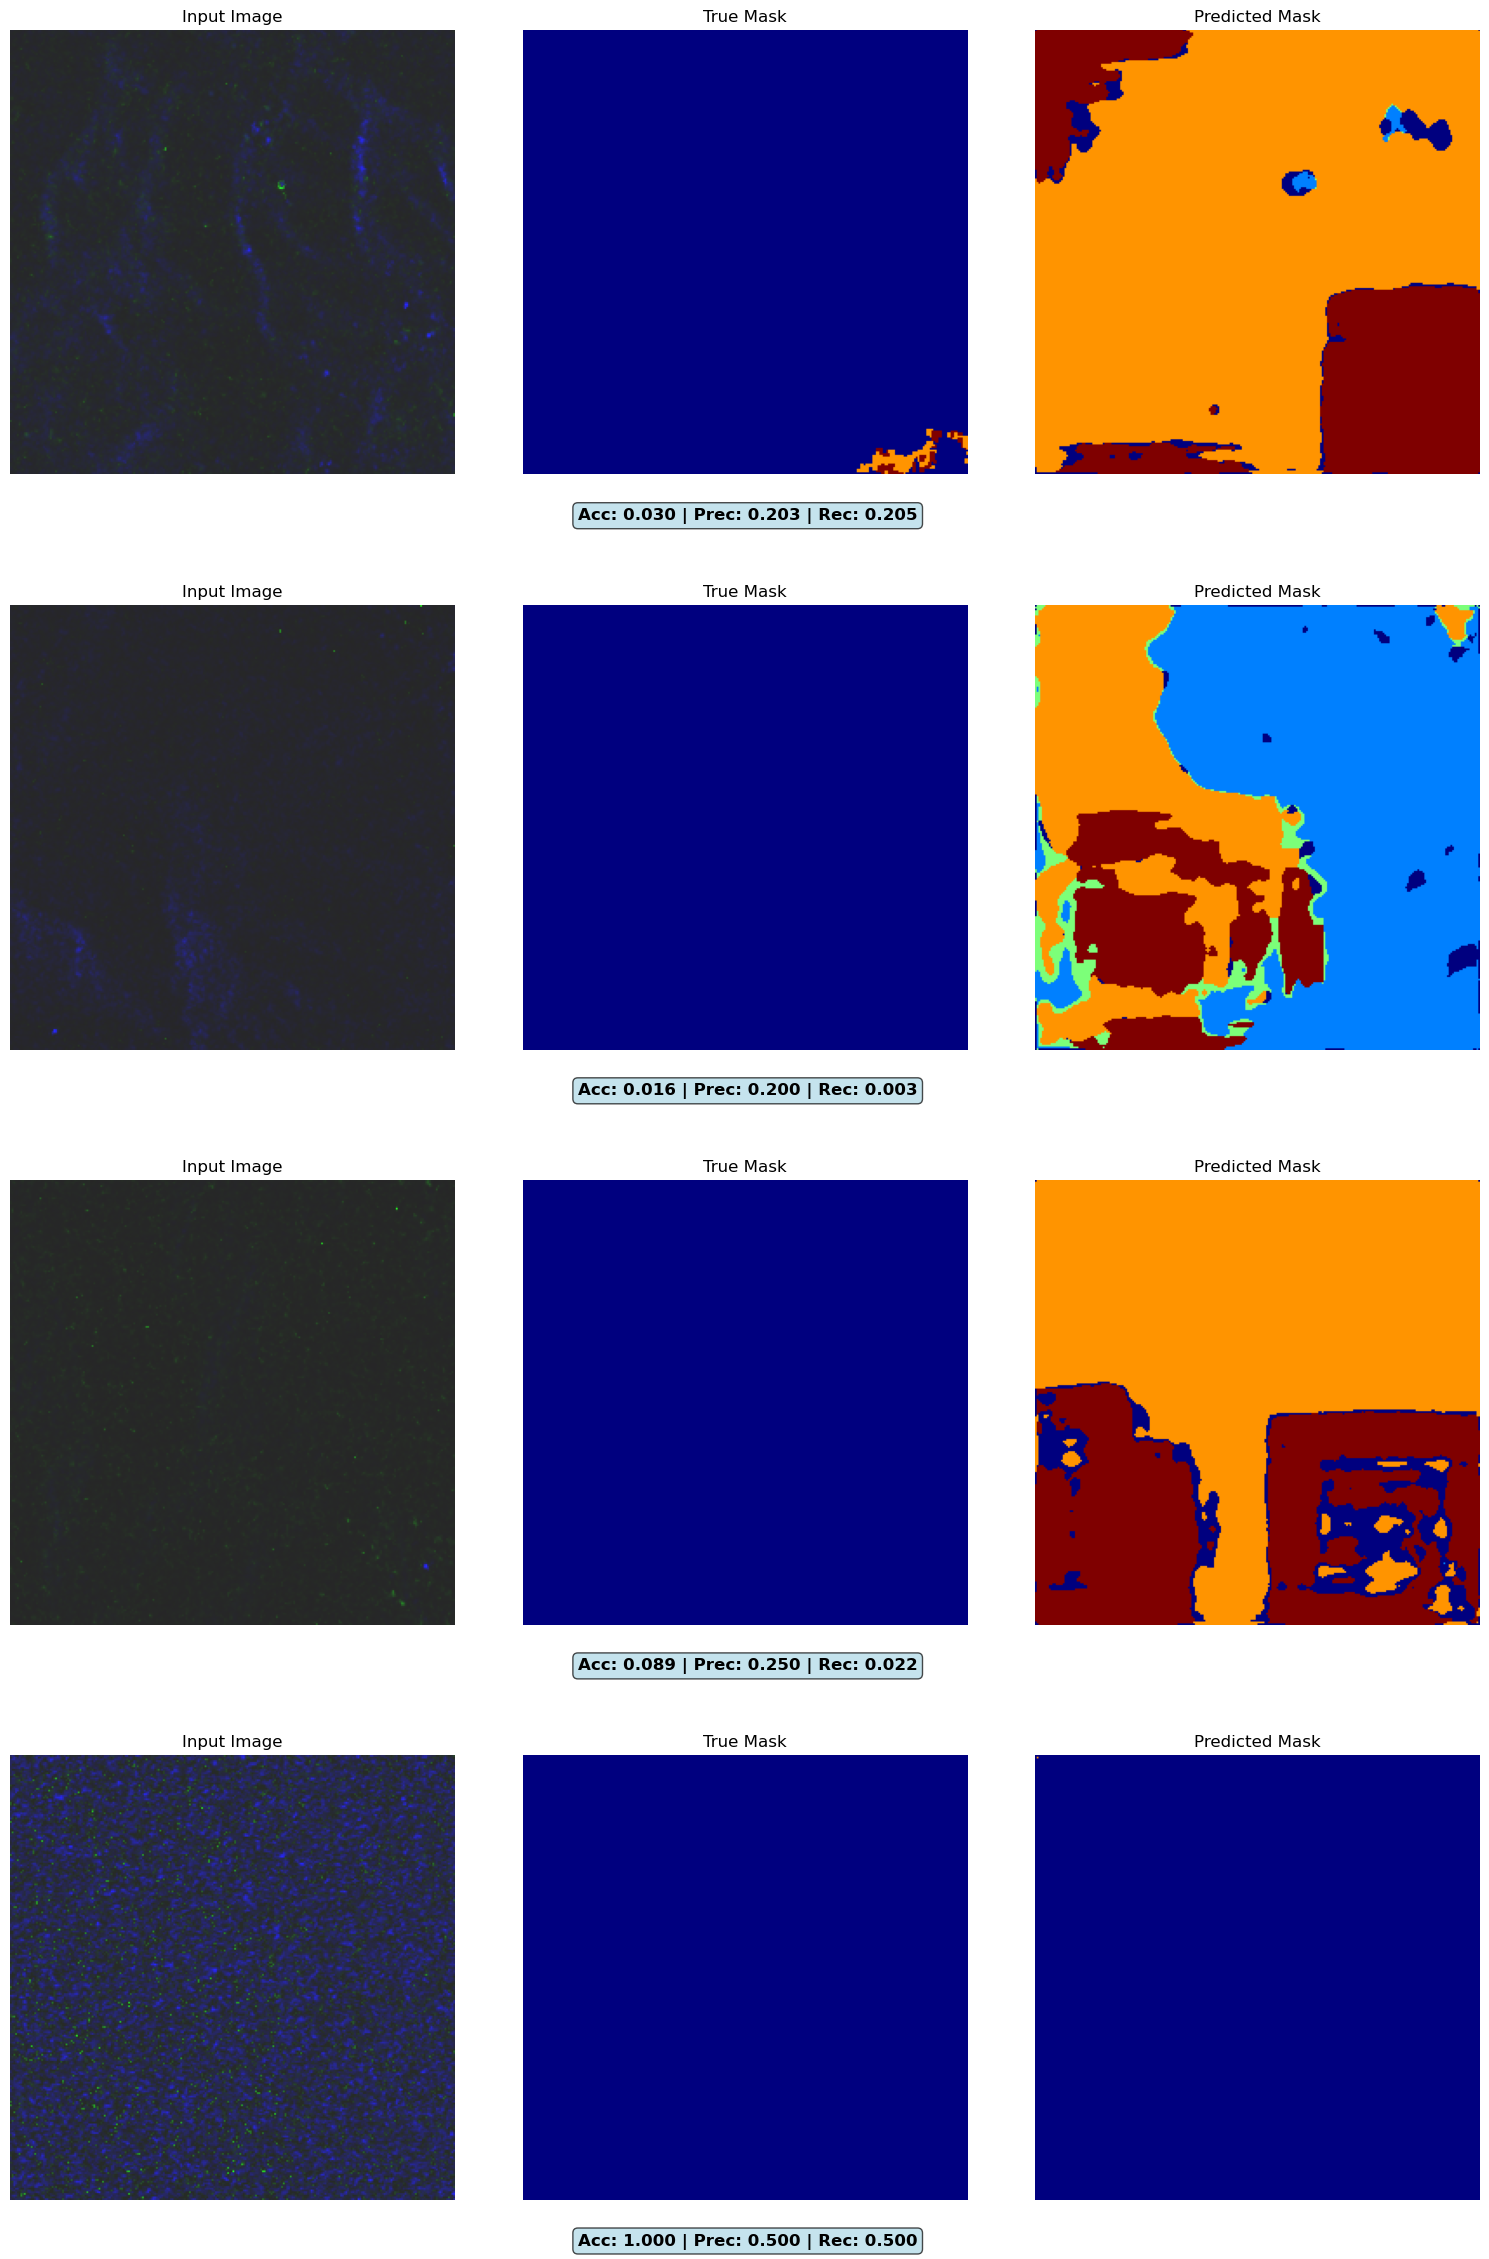

In [50]:
visualize_predictions(images=test_images_sample, 
                      true_masks=test_true_masks_sample,
                      predictions=test_pred_masks_sample, 
                      num_samples=4, num_classes=5
                      )

## 2.4. Classification metrics

We use several classification metrics to assess the performance of the model, including accuracy, precision, recall, F1 and intersection over union (IoU), as well as the confusion metrics for multi-class classification.

### Confusion matrix

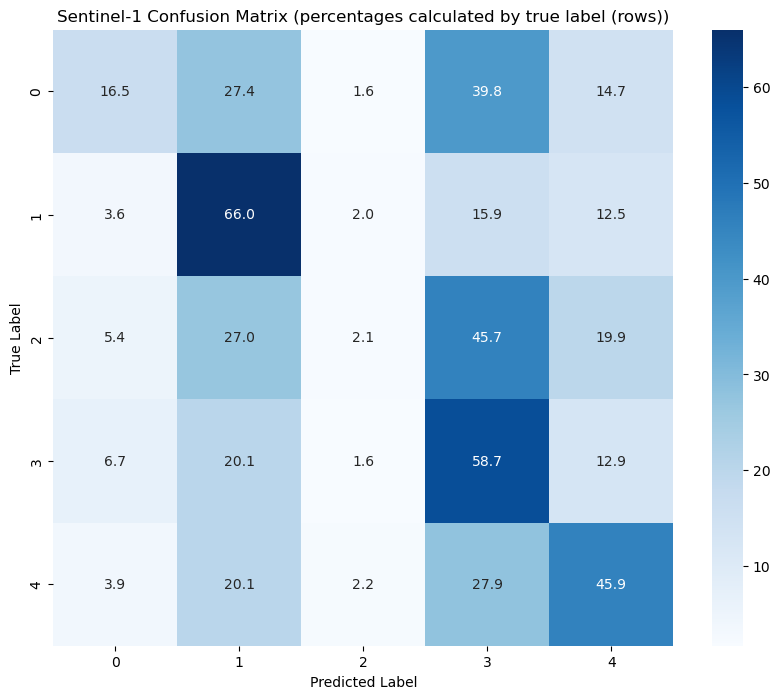

In [55]:
# Flatten the predictions and labels to 1D arrays for confusion matrix calculation
y_pred_flat = test_predictions.flatten()
y_true_flat = test_labels.flatten()

# Convert to numpy arrays if they're not already
if torch.is_tensor(y_pred_flat):
    y_pred_flat = y_pred_flat.cpu().numpy()
    y_true_flat = y_true_flat.cpu().numpy()

# Define class names for the plot
class_names = ['0', '1', '2', '3', '4']

# Compute confusion matrix
conf_matrix = confusion_matrix(y_true_flat, y_pred_flat)
conf_pct = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis] * 100

# Visualization of confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_pct, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Sentinel-1 Confusion Matrix (percentages calculated by true label (rows))')
plt.show()

C:\Users\blanc\AppData\Local\Temp\ipykernel_34696\2217914161.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = plt.cm.get_cmap('jet')


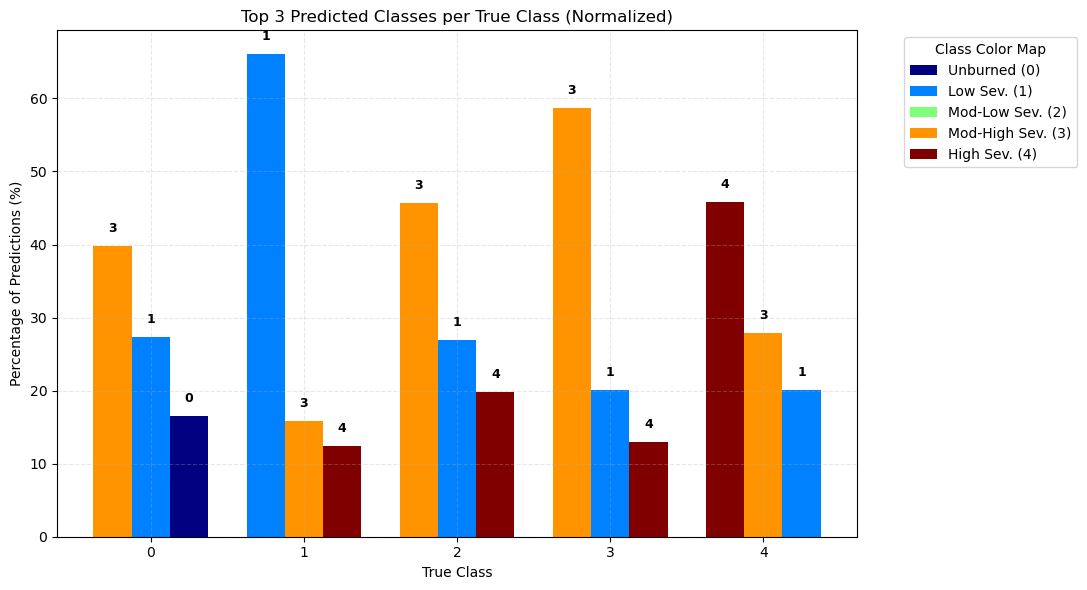

In [52]:
class_names = ['Unburned (0)', 'Low Sev. (1)', 'Mod-Low Sev. (2)', 'Mod-High Sev. (3)', 'High Sev. (4)']

# Normalize confusion matrix rows to get percentages
conf_matrix_pct = conf_matrix.astype(float)
row_sums = conf_matrix_pct.sum(axis=1, keepdims=True)
conf_matrix_pct = np.divide(conf_matrix_pct, row_sums, where=row_sums != 0) * 100  # avoid div by zero

# Use 'jet' colormap to match the mask visualizations
jet = plt.cm.get_cmap('jet')
colors = [jet(i / 4) for i in range(5)]  # class 0 = blue, class 4 = red

# Get top-3 predictions per true class
top3_preds  = np.argsort(conf_matrix_pct, axis=1)[:, ::-1][:, :3]  # shape (5, 3)
top3_values = np.take_along_axis(conf_matrix_pct, top3_preds, axis=1)

# Plotting
n_classes = conf_matrix.shape[0]
x = np.arange(n_classes)
width = 0.25

fig, ax = plt.subplots(figsize=(11, 6))
for k in range(3):
    preds = top3_preds[:, k]
    values = top3_values[:, k]
    pos = x + (k - 1) * width
    bar_colors = [colors[p] for p in preds]
    bars = ax.bar(pos, values, width, label=f"#{k+1} Prediction", color=bar_colors)

    # Add predicted class number on top of each bar
    for bar, p in zip(bars, preds):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1.5,  # slightly above the bar
            f"{p}",
            ha='center', va='bottom', fontsize=9, fontweight='bold'
        )

# Axes and labels
ax.set_xticks(x)
ax.set_xticklabels([f"{i}" for i in range(n_classes)])
ax.set_xlabel("True Class")
ax.set_ylabel("Percentage of Predictions (%)")
ax.set_title("Top 3 Predicted Classes per True Class (Normalized)")
ax.grid(alpha=0.3, linestyle='--')

# Create a custom legend for class colors
class_legend_handles = [
    Patch(facecolor=colors[i], label=class_names[i]) for i in range(n_classes)
]
ax.legend(handles=class_legend_handles, title="Class Color Map", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

### Full classification report

In [54]:
# Calculate IoU
jaccard_metric = classification.MulticlassJaccardIndex(5).to(device)  # Initialize metrics
# Move tensors to the same device as the metrics to avoid errors
test_predictions_device = test_predictions.to(device)
test_labels_device = test_labels.to(device)
# Calculate metrics (make sure inputs are tensors)
iou_torch = jaccard_metric(test_predictions_device, test_labels_device)

# Define class names for the report
class_names = ['Unburned (0)', 'Low Sev. (1)', 'Mod-Low Sev. (2)', 'Mod-High Sev. (3)', 'High Sev. (4)']

print(classification_report(y_true_flat, y_pred_flat, 
                           target_names=class_names))

                   precision    recall  f1-score   support

     Unburned (0)       0.94      0.17      0.28  25435478
     Low Sev. (1)       0.23      0.66      0.34   3339163
 Mod-Low Sev. (2)       0.03      0.02      0.02    767321
Mod-High Sev. (3)       0.03      0.59      0.06    634747
    High Sev. (4)       0.10      0.46      0.16   1018427

         accuracy                           0.23  31195136
        macro avg       0.27      0.38      0.17  31195136
     weighted avg       0.80      0.23      0.27  31195136



# 3. Conclusions

The performance of this model is significantly poorer. We can see from the printed images that there does not seem to be any clear pattern, with the predictions seeming almost arbitrary. This can be further confimred seeing the confusion matrix and the bar plot below, showing a class prediction pattern that also seems very far from having found a pattern in the data. 

This is especially interesting given that this model was trained on 100 more epochs than the Sentinel-2 one, so it should have reached further. 

One of the reasons for this could be that the number of bands in these images, 4, as opposed to the 13 bands in the other ones, means that we have about 1/3 of the data on which to train the model. It could also, and most probably, mean that the most relevant information to detect fire damage is found on color-frequency bands and not on polarised signals.